In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
  Using cached scienceplots-2.2.2-py3-none-any.whl.metadata (14 kB)
Using cached scienceplots-2.2.2-py3-none-any.whl (33 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
J = sp.Symbol("J", real=True, positive=True)
epsilon = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)
delta = sp.Symbol("delta", real=True, positive=True)
Delta1, Delta2, Delta3  = sp.symbols("Delta1 Delta2 Delta3", real=True, positive=True)
Delta31, Delta32, Delta21 = sp.symbols("Delta31 Delta32 Delta21", real=True, positive=True)
t = sp.Symbol("t", real=True, positive=True)


# n=4

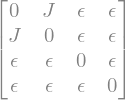

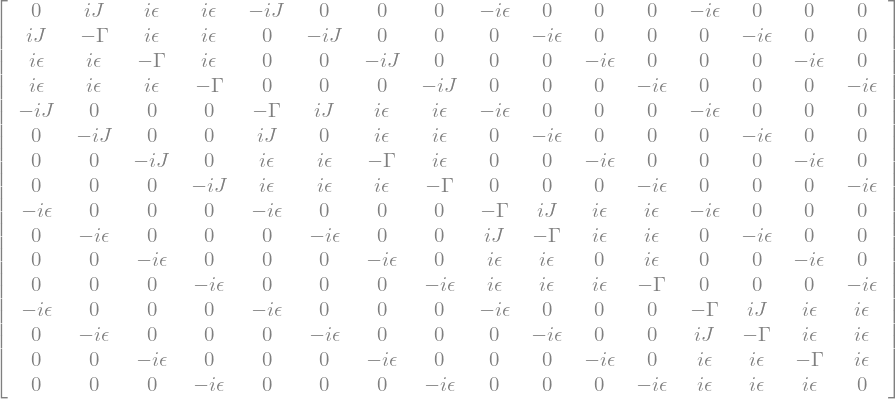

In [11]:
H = sp.Matrix([[0, J, epsilon, epsilon],
               [J, 0, epsilon, epsilon],
               [epsilon, epsilon, 0, epsilon],
               [epsilon, epsilon, epsilon, 0]])


L, rho = lindbladian(4, output=False, degenerate=False, H=H)

# dephasing
L = L.subs({sp.Symbol(f"Gamma_{i}→{i}", real=True, nonnegative=True): gamma for i in range(64)})

# no population transitions
L = L.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(64) for j in range(64)})

# writing in terms of site energy differences
L = L.subs({Delta3-Delta1:Delta31,Delta3-Delta2:Delta32, Delta2-Delta1:Delta21})

display(H)
display(L)

In [6]:
mathematica_code(L).replace("Gamma","Γ").replace("epsilon", "ϵ")

'{{0, I*J, I*ϵ, I*ϵ, -I*J, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0}, {I*J, -Γ, I*ϵ, I*ϵ, 0, -I*J, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0}, {I*ϵ, I*ϵ, -Γ, I*ϵ, 0, 0, -I*J, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0}, {I*ϵ, I*ϵ, I*ϵ, -Γ, 0, 0, 0, -I*J, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ}, {-I*J, 0, 0, 0, -Γ, I*J, I*ϵ, I*ϵ, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0}, {0, -I*J, 0, 0, I*J, 0, I*ϵ, I*ϵ, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0}, {0, 0, -I*J, 0, I*ϵ, I*ϵ, -Γ, I*ϵ, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0}, {0, 0, 0, -I*J, I*ϵ, I*ϵ, I*ϵ, -Γ, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ}, {-I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0, -Γ, I*J, I*ϵ, I*ϵ, -I*ϵ, 0, 0, 0}, {0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, I*J, -Γ, I*ϵ, I*ϵ, 0, -I*ϵ, 0, 0}, {0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, I*ϵ, I*ϵ, 0, I*ϵ, 0, 0, -I*ϵ, 0}, {0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, I*ϵ, I*ϵ, I*ϵ, -Γ, 0, 0, 0, -I*ϵ}, {-I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0, -Γ, I*J, I*ϵ, I*ϵ}, {0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, I*J, -Γ, I*ϵ, I*ϵ}, {0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, I*ϵ, I*ϵ, -Γ, I*ϵ}, {0, 0, 0, -

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_192/574615924.py:2: SyntaxWarning: invalid escape sequence '\['
  (-8*\[CapitalGamma]*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2)


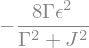

++++++++++++++++++++++++++++++


In [8]:
evals_string = '''
(-8*\[CapitalGamma]*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2)
'''

evals_approx = [parse_mathematica(evals_string.replace(r"\[CapitalGamma]", "Gamma").replace(r"\[Epsilon]", "epsilon"))]

evals_approx = [i.subs({sp.Symbol("Gamma"): gamma, sp.Symbol("epsilon"): epsilon, sp.Symbol("J"): J}) for i in evals_approx]


for i in evals_approx:
    display(i)
    print("++++++++++++++++++++++++++++++")

    


# n=5

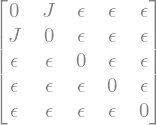

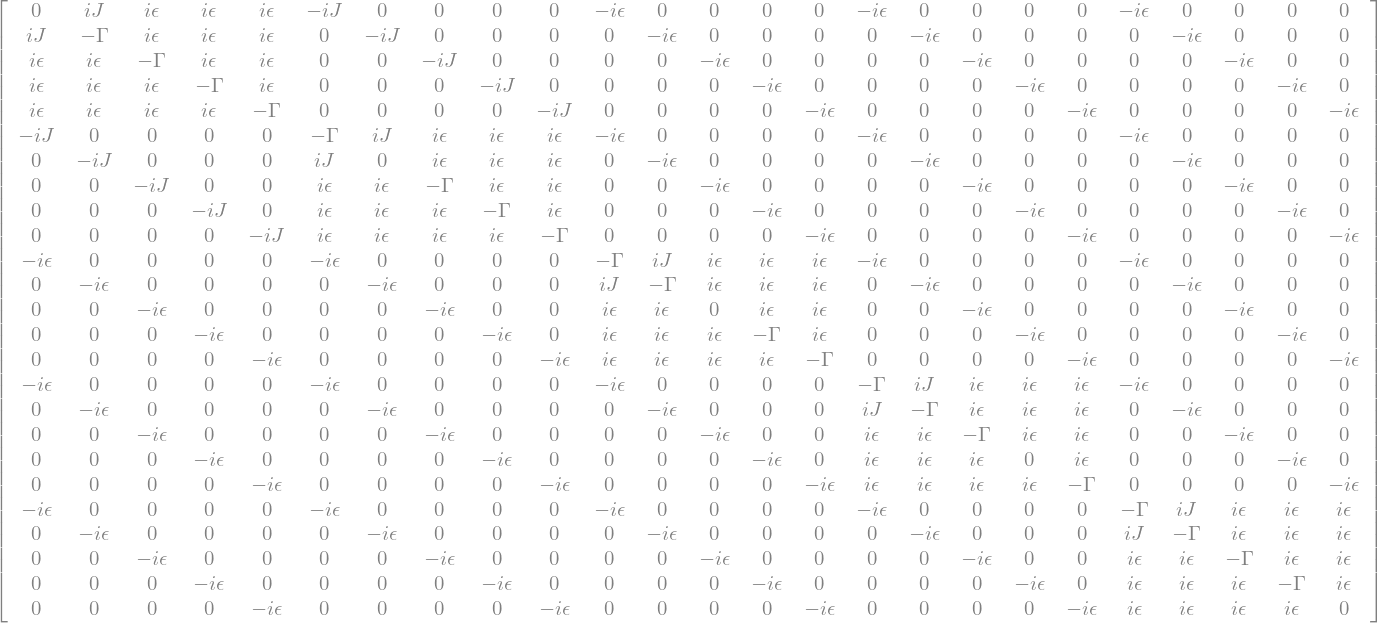

In [13]:
H = sp.Matrix([[0, J, epsilon, epsilon, epsilon], 
               [J, 0, epsilon, epsilon, epsilon], 
               [epsilon, epsilon, 0, epsilon, epsilon], 
               [epsilon, epsilon, epsilon, 0, epsilon], 
               [epsilon, epsilon, epsilon, epsilon, 0]])


L, rho = lindbladian(5, output=False, degenerate=False, H=H)

# dephasing
L = L.subs({sp.Symbol(f"Gamma_{i}→{i}", real=True, nonnegative=True): gamma for i in range(64)})

# no population transitions
L = L.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(64) for j in range(64)})

# writing in terms of site energy differences
L = L.subs({Delta3-Delta1:Delta31,Delta3-Delta2:Delta32, Delta2-Delta1:Delta21})

display(H)
display(L)

In [14]:
mathematica_code(L).replace("Gamma","Γ").replace("epsilon", "ϵ")

'{{0, I*J, I*ϵ, I*ϵ, I*ϵ, -I*J, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0}, {I*J, -Γ, I*ϵ, I*ϵ, I*ϵ, 0, -I*J, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0}, {I*ϵ, I*ϵ, -Γ, I*ϵ, I*ϵ, 0, 0, -I*J, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0}, {I*ϵ, I*ϵ, I*ϵ, -Γ, I*ϵ, 0, 0, 0, -I*J, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0}, {I*ϵ, I*ϵ, I*ϵ, I*ϵ, -Γ, 0, 0, 0, 0, -I*J, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ}, {-I*J, 0, 0, 0, 0, -Γ, I*J, I*ϵ, I*ϵ, I*ϵ, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0}, {0, -I*J, 0, 0, 0, I*J, 0, I*ϵ, I*ϵ, I*ϵ, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0}, {0, 0, -I*J, 0, 0, I*ϵ, I*ϵ, -Γ, I*ϵ, I*ϵ, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0}, {0, 0, 0, -I*J, 0, I*ϵ, I*ϵ, I*ϵ, -Γ, I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0}, {0, 0, 0, 0, -I*J, I*ϵ, I*ϵ, I*ϵ, I*ϵ, -Γ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, -I*ϵ}, {-I*ϵ, 0, 0, 0, 0, -

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_192/2719510355.py:2: SyntaxWarning: invalid escape sequence '\['
  (-10*\[CapitalGamma]*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2)


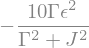

++++++++++++++++++++++++++++++


In [15]:
evals_string = '''
(-10*\[CapitalGamma]*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2)
'''

evals_approx = [parse_mathematica(evals_string.replace(r"\[CapitalGamma]", "Gamma").replace(r"\[Epsilon]", "epsilon"))]

evals_approx = [i.subs({sp.Symbol("Gamma"): gamma, sp.Symbol("epsilon"): epsilon, sp.Symbol("J"): J}) for i in evals_approx]


for i in evals_approx:
    display(i)
    print("++++++++++++++++++++++++++++++")

    

# n=6

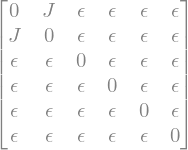

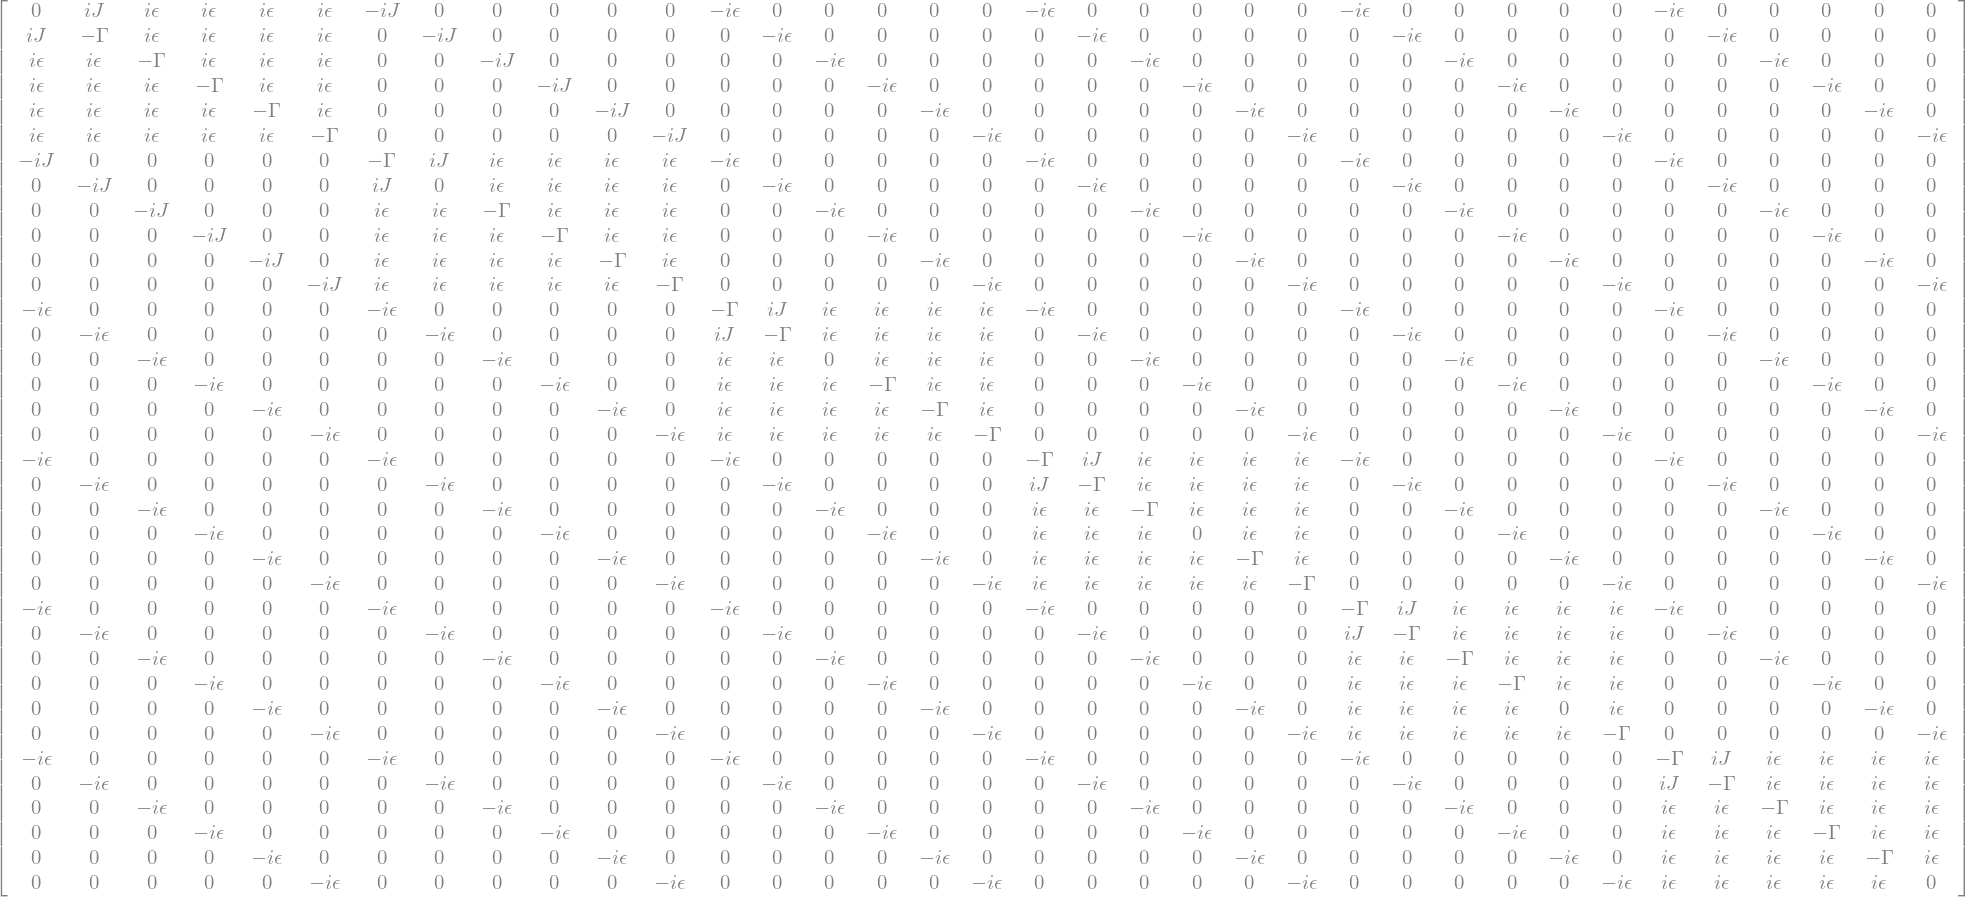

In [19]:
H = sp.Matrix([[0, J, epsilon, epsilon, epsilon, epsilon], 
               [J, 0, epsilon, epsilon, epsilon, epsilon], 
               [epsilon, epsilon, 0, epsilon, epsilon, epsilon], 
               [epsilon, epsilon, epsilon, 0, epsilon, epsilon], 
               [epsilon, epsilon, epsilon, epsilon, 0, epsilon],
               [epsilon, epsilon, epsilon, epsilon, epsilon, 0]])


L, rho = lindbladian(6, output=False, degenerate=False, H=H)

# dephasing
L = L.subs({sp.Symbol(f"Gamma_{i}→{i}", real=True, nonnegative=True): gamma for i in range(64)})

# no population transitions
L = L.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(64) for j in range(64)})


display(H)
display(L)

In [20]:
mathematica_code(L).replace("Gamma","Γ").replace("epsilon", "ϵ")

'{{0, I*J, I*ϵ, I*ϵ, I*ϵ, I*ϵ, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0}, {I*J, -Γ, I*ϵ, I*ϵ, I*ϵ, I*ϵ, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0}, {I*ϵ, I*ϵ, -Γ, I*ϵ, I*ϵ, I*ϵ, 0, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0}, {I*ϵ, I*ϵ, I*ϵ, -Γ, I*ϵ, I*ϵ, 0, 0, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0}, {I*ϵ, I*ϵ, I*ϵ, I*ϵ, -Γ, I*ϵ, 0, 0, 0, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0}, {I*ϵ, I*ϵ, I*ϵ, I*ϵ, I*ϵ, -Γ, 0, 0, 0, 0, 0, -I*J, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ}, {-I*J, 0, 0, 0, 0, 0, -Γ, I*J, I*ϵ, I*ϵ, I*ϵ, I*ϵ, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0, -I*ϵ, 0, 0, 0, 0, 0}, {0, -I*J, 0, 0, 0, 0, I*J, 0, I*ϵ, I*ϵ, I*ϵ, I*

In [4]:
import numpy as np
a = np.arange(1,10,1)

def f(x):
    return x**2

print(f(a))

[ 1  4  9 16 25 36 49 64 81]


# perturbation theory

reference paper: https://arxiv.org/pdf/1311.3227

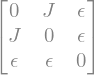

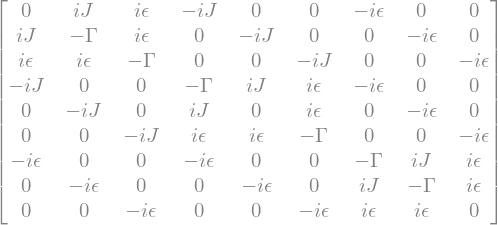

In [99]:
H = sp.Matrix([[0, J, epsilon],
               [J, 0, epsilon],
               [epsilon, epsilon, 0]])


L, rho = lindbladian(3, output=False, degenerate=False, H=H)

# dephasing
L = L.subs({sp.Symbol(f"Gamma_{i}→{i}", real=True, nonnegative=True): gamma for i in range(64)})

# no population transitions
L = L.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(64) for j in range(64)})

# writing in terms of site energy differences
L = L.subs({Delta3-Delta1:Delta31,Delta3-Delta2:Delta32, Delta2-Delta1:Delta21})

display(H)
display(L)

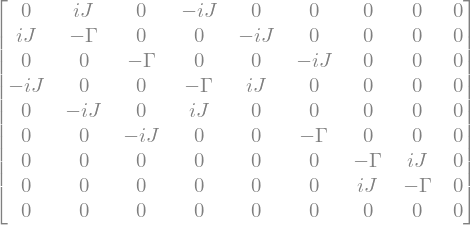

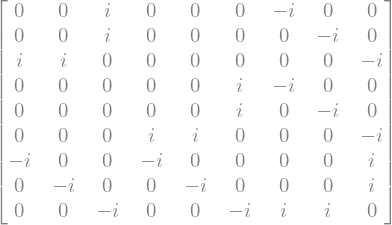

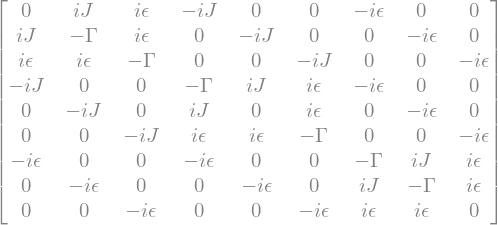

In [100]:
H0 = sp.Matrix([[0, J, 0],
               [J, 0, 0],
               [0, 0, 0]])

V = sp.Matrix([[0, 0, 1],
               [0, 0, 1],
               [1, 1, 0]])

L0, _ = lindbladian(3, output=False, degenerate=False, H=H0)
L1, _ = lindbladian(3, output=False, degenerate=False, H=V)

# dephasing
L0 = L0.subs({sp.Symbol(f"Gamma_{i}→{i}", real=True, nonnegative=True): gamma for i in range(4)})


# no population transitions
L0 = L0.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(4) for j in range(4)})
L1 = L1.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True): 0 for i in range(4) for j in range(4)})



display(L0)
display(L1)
display(L0+epsilon*L1)

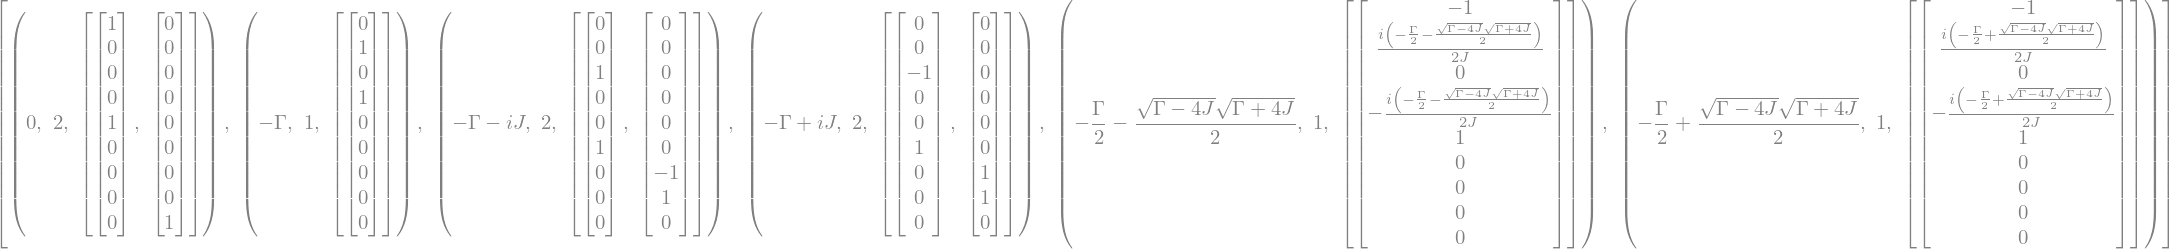

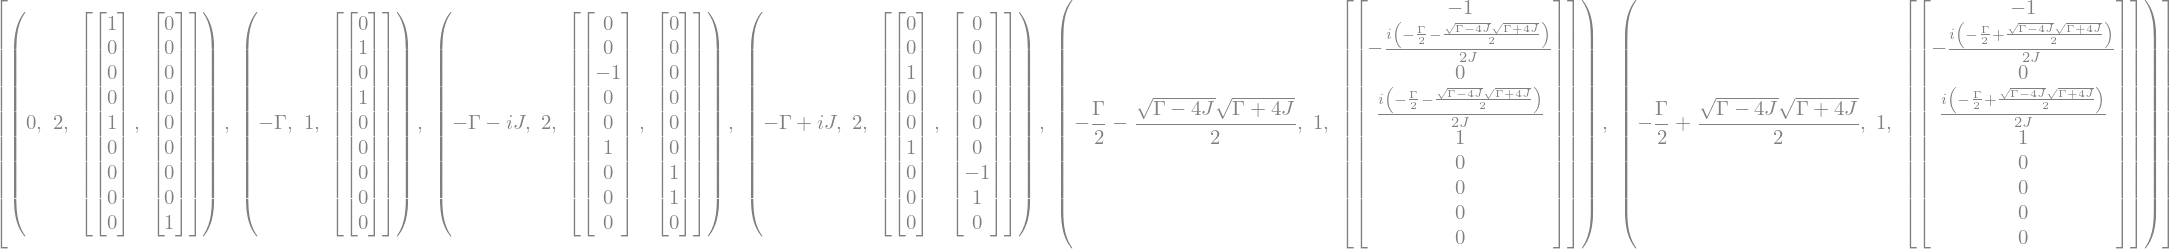

In [101]:
# computing left and right eigenvectors of L0
display(L0.eigenvects()) # right
display(Dagger(L0).eigenvects()) # left

B = L0.eigenvects()

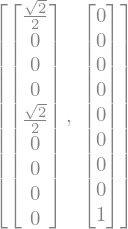

In [102]:
N = [n/n.norm() for n in L0.nullspace()]
N

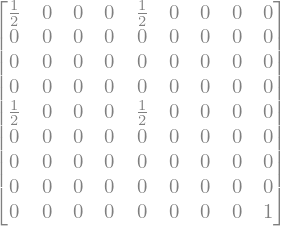

In [103]:
P = sp.Add(*[  u*u.transpose() for u in N  ])
P

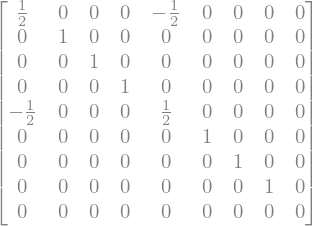

In [104]:
Q = sp.eye(sp.shape(P)[0]) - P
Q

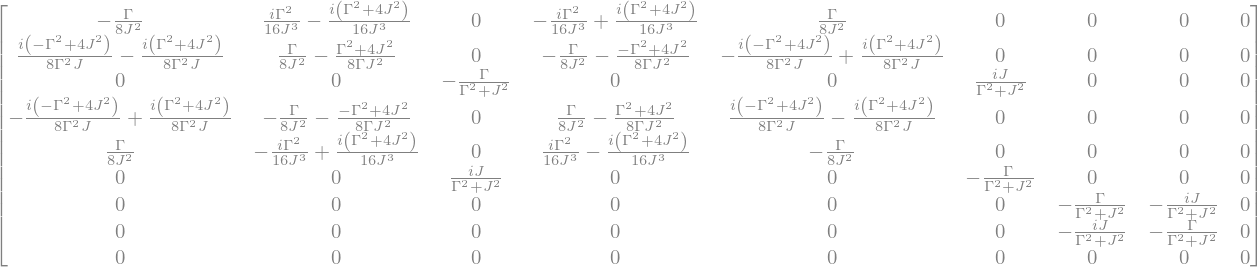

In [105]:
A = Q*L0*Q
S = Q*A.pinv()*Q
S

In [106]:
P1 = -1*P*L1*S - -1*S*L1*P

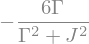

In [107]:
# second order correction

sp.Trace( P*L1*S*L1 ).simplify().together()/-1